In [3]:
from google.colab import drive
import os

import time
from datetime import datetime
import torch
from torchvision import datasets, transforms, utils
from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
def count_total_images(directory):
    total_images = 0
    for root, _, files in os.walk(directory):
        total_images += len([f for f in files if f.lower().endswith(('jpg', 'jpeg', 'png', 'bmp', 'gif'))])
    return total_images

In [6]:
fruits_and_veggies_train = "/content/drive/My Drive/DL_Dataset/Train"
fruits_and_veggies_test = "/content/drive/My Drive/DL_Dataset/Test"
dataset_path = "/content/drive/My Drive/DL_Dataset"

train_count = count_total_images(fruits_and_veggies_train)
test_count = count_total_images(fruits_and_veggies_test)
total_images = count_total_images(dataset_path)

print(f"Training set contains {train_count} images")
print(f"Test set contains {test_count} images")
print(f"Total number of images in the dataset: {total_images}")

Training set contains 23629 images
Test set contains 6738 images
Total number of images in the dataset: 30367


In [7]:
# Define the classes you want to filter
classifications = ['freshapples', 'rottenapples']

In [8]:
class FilteredImageFolder(Dataset):
    def __init__(self, root, transform=None, classes=None):
        # Create the ImageFolder dataset
        self.dataset = datasets.ImageFolder(root, transform=transform)

        # If classes are provided, filter the dataset by the given classes
        if classes:
            # Create a mapping of class names to the filtered indices
            self.class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
            # Print the class-to-index mapping
            print("Class to Index Mapping:", self.class_to_idx)
            # Filter samples to include only those from the filtered classes
            self.samples = [(path, self.class_to_idx[self.dataset.classes[target]])
                            for path, target in self.dataset.samples
                            if self.dataset.classes[target] in classes]
        else:
            self.class_to_idx = self.dataset.class_to_idx
            self.samples = self.dataset.samples

    def __getitem__(self, index):
        # Return the image and the corresponding label
        path, target = self.samples[index]
        sample = self.dataset.loader(path)
        if self.dataset.transform:
            sample = self.dataset.transform(sample)
        return sample, target

    def __len__(self):
        return len(self.samples)

In [9]:
dataset_transform  = {'Train':transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
]),
                       'Test':transforms.Compose([
                           transforms.Resize((224,224)),
                           transforms.ToTensor(),
                           transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                       ])}


samples_datasets = {
    'Train': FilteredImageFolder(os.path.join(dataset_path, 'Train'), transform=dataset_transform['Train'], classes=classifications),
    'Test': FilteredImageFolder(os.path.join(dataset_path, 'Test'), transform=dataset_transform['Test'], classes=classifications)
}

dataset_loader = {
    'Train': torch.utils.data.DataLoader(samples_datasets['Train'], batch_size=124, shuffle=True, num_workers=0),
    'Test': torch.utils.data.DataLoader(samples_datasets['Test'], batch_size=124, shuffle=False, num_workers=0)
}

Class to Index Mapping: {'freshapples': 0, 'rottenapples': 1}
Class to Index Mapping: {'freshapples': 0, 'rottenapples': 1}


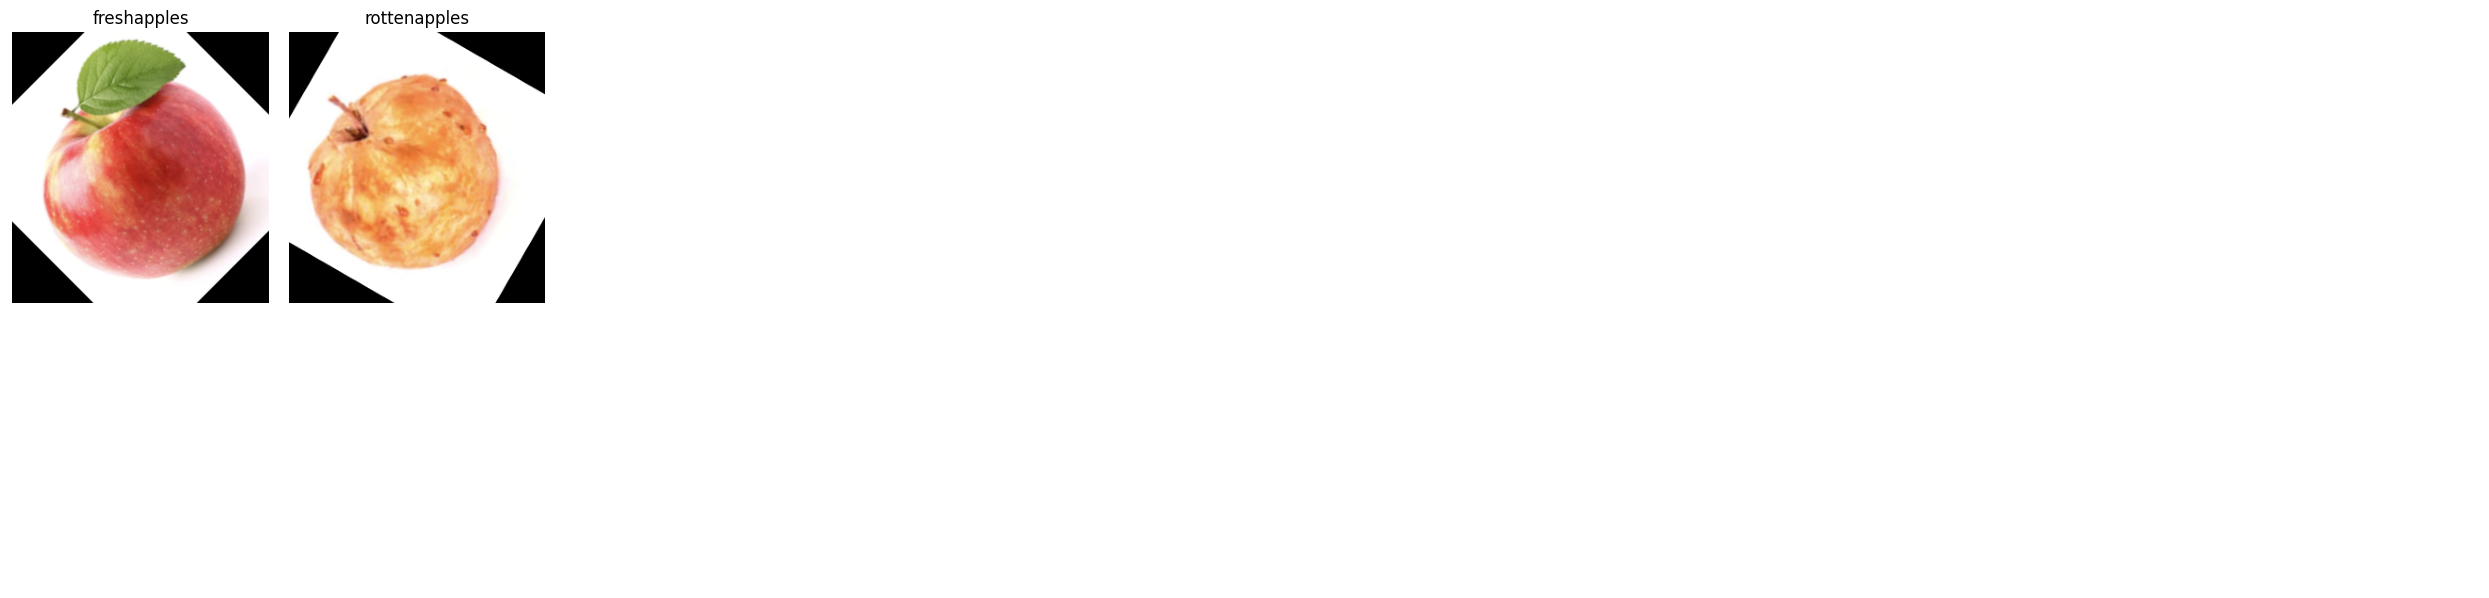

In [10]:
num_classes = len(classifications)
rows, cols = 2, 9  # 2x9 grid
fig, axes = plt.subplots(rows, cols, figsize=(25, 6))


axes = axes.flatten()

# Plot one exemplar from each class
for i, class_name in enumerate(classifications):
    class_path = os.path.join(fruits_and_veggies_train, class_name)
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

    if image_files:  # Ensure the class folder is not empty
        img_path = os.path.join(class_path, image_files[0])  # Select first image
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(class_name)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [11]:
KERNELS = 3
PADDINGS = 1
EPOCHS = 10

In [12]:
# Network definition
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=KERNELS, padding=PADDINGS)  # Example kernel size and padding
        self.conv2 = nn.Conv2d(16, 8, kernel_size=KERNELS, padding=PADDINGS)
        self.fc1 = nn.Linear(8 * 56 * 56, 56)
        self.fc2 = nn.Linear(56, len(classifications))  # Adjust output size based on filtered classes
        self.relu = nn.ReLU()

    def forward(self, x):
        x = F.max_pool2d(self.relu(self.conv1(x)), 2)
        x = F.max_pool2d(self.relu(self.conv2(x)), 2)
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the network
net = Net()

# Optimizer and loss function
optimiser = optim.Adam(net.parameters(), lr=0.001)
cross_entropy_loss = nn.CrossEntropyLoss()

# Initialize lists to store metrics for plotting
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

# Training loop
for epoch in range(EPOCHS):

    epoch_start_time = time.time()  # Start timing the epoch
    start_datetime = datetime.fromtimestamp(epoch_start_time)
    print(f"Start Time: {start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")

    net.train()  # Set the model to training mode
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    # Training phase
    for data in dataset_loader['Train']:
        x, y = data
        optimiser.zero_grad()  # Ensure gradients are zeroed before the backward pass
        output = net(x)  # Forward pass
        loss = cross_entropy_loss(output, y)  # Compute loss
        loss.backward()  # Backward pass
        optimiser.step()  # Update the parameters

        # Track the training loss
        running_train_loss += loss.item()

        # Track the training accuracy
        _, predicted = torch.max(output, 1)
        correct_train += (predicted == y).sum().item()
        total_train += y.size(0)

    # Calculate and store average training loss and accuracy for this epoch
    avg_train_loss = running_train_loss / len(dataset_loader['Train'])
    train_accuracy = 100 * correct_train / total_train

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")

    # Evaluation phase
    net.eval()  # Set the model to evaluation mode
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0

    with torch.no_grad():  # No need to compute gradients during testing
        for data in dataset_loader['Test']:
            x, y = data
            output = net(x)
            loss = cross_entropy_loss(output, y)  # Compute test loss

            # Track the test loss
            running_test_loss += loss.item()

            # Track the test accuracy
            _, predicted = torch.max(output, 1)
            correct_test += (predicted == y).sum().item()
            total_test += y.size(0)

    # Calculate and store average test loss and accuracy for this epoch
    avg_test_loss = running_test_loss / len(dataset_loader['Test'])
    test_accuracy = 100 * correct_test / total_test

    test_losses.append(avg_test_loss)
    test_accuracies.append(test_accuracy)

    print(f"Epoch [{epoch+1}/{EPOCHS}], Validation Loss: {avg_test_loss:.4f}, Validation Accuracy: {test_accuracy:.2f}%")


epoch_end_time = time.time()
end_datetime = datetime.fromtimestamp(epoch_end_time)
print(f"End Time: {end_datetime.strftime('%Y-%m-%d %H:%M:%S')}")


Start Time: 2025-04-13 06:20:28
Epoch [1/10], Train Loss: 0.5754, Train Accuracy: 73.87%
Epoch [1/10], Validation Loss: 0.2706, Validation Accuracy: 87.18%
Start Time: 2025-04-13 06:45:15
Epoch [2/10], Train Loss: 0.1975, Train Accuracy: 91.34%
Epoch [2/10], Validation Loss: 0.1793, Validation Accuracy: 91.85%
Start Time: 2025-04-13 06:50:28
Epoch [3/10], Train Loss: 0.1546, Train Accuracy: 93.67%
Epoch [3/10], Validation Loss: 0.1841, Validation Accuracy: 92.58%
Start Time: 2025-04-13 06:55:23
Epoch [4/10], Train Loss: 0.1303, Train Accuracy: 95.03%
Epoch [4/10], Validation Loss: 0.1352, Validation Accuracy: 94.15%
Start Time: 2025-04-13 07:00:38
Epoch [5/10], Train Loss: 0.1041, Train Accuracy: 96.21%
Epoch [5/10], Validation Loss: 0.1039, Validation Accuracy: 95.67%
Start Time: 2025-04-13 07:05:43
Epoch [6/10], Train Loss: 0.0840, Train Accuracy: 96.81%
Epoch [6/10], Validation Loss: 0.0885, Validation Accuracy: 96.68%
Start Time: 2025-04-13 07:11:00
Epoch [7/10], Train Loss: 0.0665

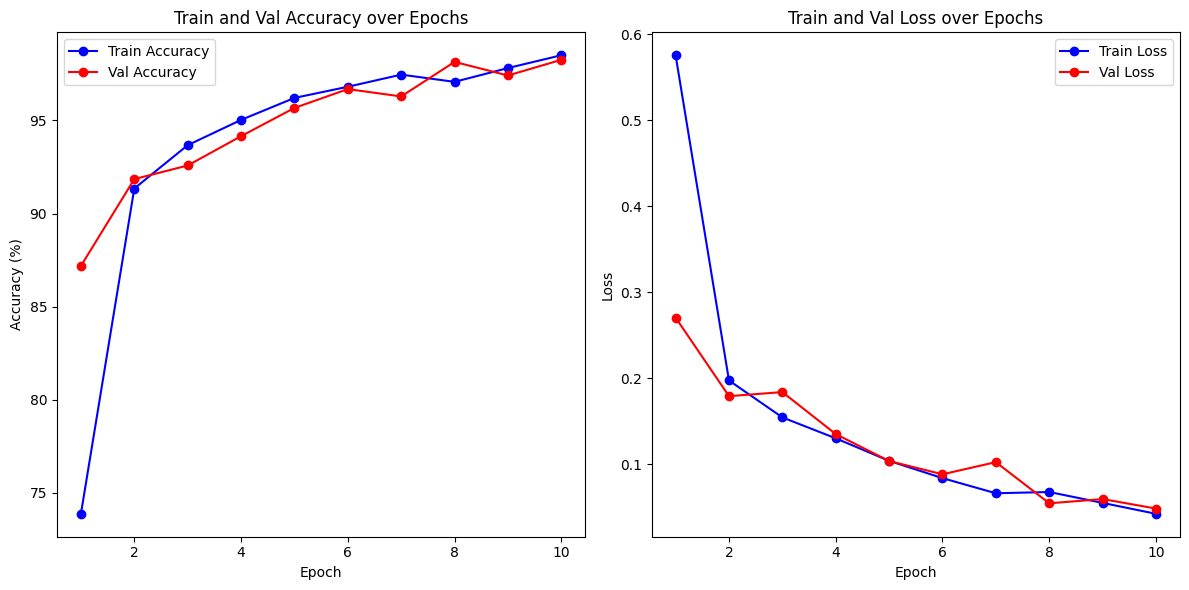

In [13]:
# After training loop, plot the metrics
epochs = range(1, EPOCHS + 1)

# Plot Accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, label='Train Accuracy', color='blue', marker='o')
plt.plot(epochs, test_accuracies, label='Val Accuracy', color='red', marker='o')
plt.title('Train and Val Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(epochs, test_losses, label='Val Loss', color='red', marker='o')
plt.title('Train and Val Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

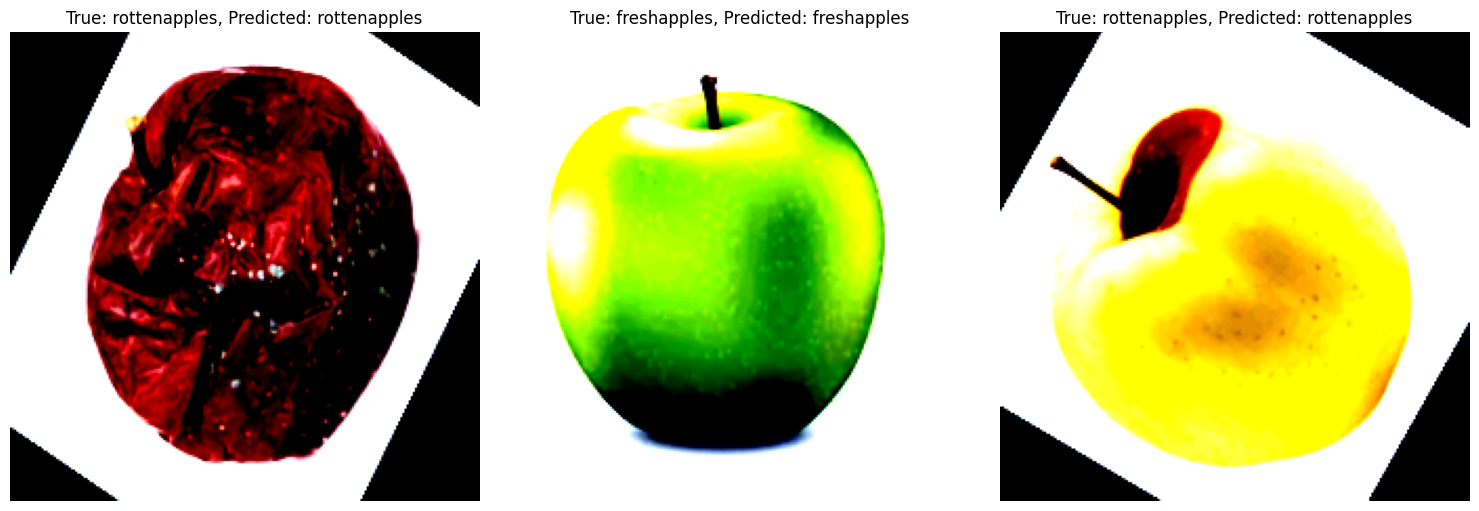

In [14]:
import random
import warnings
warnings.filterwarnings("ignore")

# Set model to evaluation mode
net.eval()

# Get 3 random samples from the test dataset
test_dataset = dataset_loader['Test'].dataset  # Access the underlying dataset
indices = random.sample(range(len(test_dataset)), 3)
samples = [test_dataset[i] for i in indices]

# Create plots for predictions
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

with torch.no_grad():
    for i, (x, y_true) in enumerate(samples):
        x_input = x.unsqueeze(0)  # Add batch dimension
        output = net(x_input)
        _, y_pred = torch.max(output, 1)

        # Plot the image
        axs[i].imshow(x.permute(1, 2, 0))  # Convert from CxHxW to HxWxC
        axs[i].set_title(f"True: {classifications[y_true]}, Predicted: {classifications[y_pred.item()]}")
        axs[i].axis('off')

plt.tight_layout()
plt.show()
